<a href="https://colab.research.google.com/github/wubadou3/python_text_analysis_final/blob/main/Final_Project_processing_and_visuals_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 2: Data Processing and Visualization


In [ ]:
# ========================================
# Part 1: Get the data ready for analysis
# ========================================

#0. Mount drive and get library ready

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

#1. Load Factiva CSV
factiva_path = "/content/drive/MyDrive/factiva_final_project/factiva.csv"
news_raw = pd.read_csv(factiva_path)

print("Raw shape:", news_raw.shape)
print(news_raw.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw shape: (1740, 8)
   index                                           Headline Publication_Date  \
0      1       Congress Can Make the Fed Focus on Inflation       2024-12-04   
1      1  Markets & Finance -- Tuesday's Markets: Invest...       2024-12-04   
2      1              Markets & Finance: Wednesday's Events       2024-12-04   

               Source_Name                                     Lead Paragraph  \
0  The Wall Street Journal  Judy Shelton is right: "Trump Should Challenge...   
1  The Wall Street Journal  The S&P 500 and Nasdaq Composite hit records o...   
2  The Wall Street Journal  The ADP employment report is due at 8:15 a.m.,...   

                                                Body  \
0  With Mr. Trump in command, we have an opportun...   
1  The S&P 500 and Nasdaq Composite climbed to re...   
2  European Central Bank President C

In [ ]:
# 2. Ensure Publication_Date is a proper datetime
if "Publication_Date" not in news_raw.columns:
    raise ValueError("Expected a 'Publication_Date' column in factiva.csv")

news_raw["Publication_Date"] = pd.to_datetime(news_raw["Publication_Date"], errors="coerce")

# Drop rows where date parsing failed
news_raw = news_raw.dropna(subset=["Publication_Date"])

In [ ]:
# 3. Keep a clean, compact DataFrame for later analysis with columns needed
news_df = news_raw.copy()

cols_to_keep = []
for col in ["Publication_Date", "Headline", "Source_Name", "Author_Name"]:
    if col in news_df.columns:
        cols_to_keep.append(col)

news_df = news_df[cols_to_keep]

In [ ]:
# 4. Add convenience columns for grouping by day
news_df["date"] = news_df["Publication_Date"].dt.date

print("Cleaned news_df shape:", news_df.shape)
print(news_df.head(3))

Cleaned news_df shape: (1740, 5)
  Publication_Date                                           Headline  \
0       2024-12-04       Congress Can Make the Fed Focus on Inflation   
1       2024-12-04  Markets & Finance -- Tuesday's Markets: Invest...   
2       2024-12-04              Markets & Finance: Wednesday's Events   

               Source_Name                           Author_Name        date  
0  The Wall Street Journal                                   NaN  2024-12-04  
1  The Wall Street Journal  By Vicky Ge Huang and Caitlin McCabe  2024-12-04  
2  The Wall Street Journal                                   NaN  2024-12-04  


In [ ]:
# ==============================================
# Part 2: BERT (FinBERT) sentiment on headlines
# ==============================================

# I used chatgpt to learn about how to use FinBERT to conduct sentiment analysis because it's not covered in class.
# I asked chatgpt to generate code needed to conduct sentiment analysis using FinBERT for text,
#   and it returned code 1-3 (I tweaked it a little bit to fit my dataset)

!pip install -q transformers torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

# 1. Load FinBERT model and tokenizer
model_name = "ProsusAI/finbert"

device = 0 if torch.cuda.is_available() else -1  # use GPU if available

finbert_pipeline = pipeline(
    task="sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    device=device
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cpu


In [ ]:
# 2. Helper to run sentiment in batches over all headlines
def run_finbert_sentiment(text_series, batch_size=32):
    """
    text_series: Pandas Series of strings (e.g., news_df['text'])
    Returns: list of dicts [{'label': 'positive/negative/neutral', 'score': float}, ...]
    """
    results = []
    # Ensure we have a simple list of strings
    texts = text_series.fillna("").astype(str).tolist()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        # truncation=True so very long texts do not break BERT's max length
        batch_results = finbert_pipeline(batch, truncation=True)
        results.extend(batch_results)

    return results

In [ ]:
# 3. Apply FinBERT to each headline
if "Headline" not in news_df.columns:
    raise ValueError("Expected a 'Headline' column in news_df for headline-only sentiment.")

headline_series = news_df["Headline"].fillna("").astype(str)

print("Running FinBERT sentiment on", len(headline_series), "headlines...")
finbert_results = run_finbert_sentiment(headline_series)

# Convert list of dicts into columns
news_df["finbert_label"] = [r["label"] for r in finbert_results]
news_df["finbert_score"] = [r["score"] for r in finbert_results]

Running FinBERT sentiment on 1740 headlines...


In [ ]:
# 4. Convert labels into a numeric sentiment score

# I asked chatgpt how to use the results I have after the previous codes,
#   chatgpt walked me through what a typical output should look like,
#   and suggested that I can use label*Confidence format for the score.
# Then I asked chatgpt to generate the codes for me for defining the score function and create a merged df
#    It returned code part 4-5.

label_to_sign = {
    "positive": 1,
    "negative": -1,
    "neutral": 0
}

def compute_numeric_sentiment(label, score):
    # Some models might output uppercase labels; normalize to lowercase.
    if isinstance(label, str):
        key = label.lower()
    else:
        key = label
    sign = label_to_sign.get(key, 0)
    return sign * score

news_df["finbert_sentiment"] = news_df.apply(
    lambda row: compute_numeric_sentiment(row["finbert_label"], row["finbert_score"]),
    axis=1
)


In [ ]:
# 5. Aggregate daily sentiment for later merge with volatility data
daily_finbert_sentiment = (
    news_df
    .groupby("date")
    .agg(
        finbert_sentiment_mean=("finbert_sentiment", "mean"),
        finbert_sentiment_median=("finbert_sentiment", "median"),
        finbert_pos_share=("finbert_label", lambda x: (x.str.lower() == "positive").mean()),
        finbert_neg_share=("finbert_label", lambda x: (x.str.lower() == "negative").mean()),
        finbert_neu_share=("finbert_label", lambda x: (x.str.lower() == "neutral").mean()),
    )
    .reset_index()
)

print("Daily FinBERT sentiment shape:", daily_finbert_sentiment.shape)
print(daily_finbert_sentiment.head())

Daily FinBERT sentiment shape: (301, 6)
         date  finbert_sentiment_mean  finbert_sentiment_median  \
0  2024-12-04               -0.189314                   0.00000   
1  2024-12-05                0.351573                   0.29075   
2  2024-12-06               -0.127012                   0.00000   
3  2024-12-07               -0.015644                   0.00000   
4  2024-12-09               -0.143789                   0.00000   

   finbert_pos_share  finbert_neg_share  finbert_neu_share  
0           0.000000           0.333333           0.666667  
1           0.500000           0.000000           0.500000  
2           0.125000           0.250000           0.625000  
3           0.166667           0.166667           0.666667  
4           0.000000           0.333333           0.666667  


In [ ]:
# ================================================
# Part 3: TF-IDF features on daily HEADLINES only
# ================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Safety check: make sure we have headlines
if "Headline" not in news_df.columns:
    raise ValueError("Expected a 'Headline' column in news_df for TF-IDF on headlines.")

# 2. Build a daily-level headline corpus
#    Each row = one date, with all that day's headlines concatenated.

# Here I tried to build the code based on codes from Week3 notebook, but it always return error,
#   So I asked chatgpt to fix the codes for me and part 2-3 is the return.

daily_news_tfidf = (
    news_df
    .groupby("date")["Headline"]
    .apply(lambda xs: " ".join(xs.fillna("").astype(str)))
    .reset_index(name="joined_headlines")
)

print("Daily corpus for TF-IDF (headline-only):", daily_news_tfidf.shape)
print(daily_news_tfidf.head(3))


Daily corpus for TF-IDF (headline-only): (301, 2)
         date                                   joined_headlines
0  2024-12-04  Congress Can Make the Fed Focus on Inflation M...
1  2024-12-05  Dow Closes Above 45000 as Indexes Hit Records ...
2  2024-12-06  U.S. News: Productivity Boom Propels Economic ...


In [ ]:
# 3. Fit a TF-IDF vectorizer on the daily headline documents

#
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,          # cap vocabulary size
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=2,                   # ignore very rare terms
    stop_words="english"        # filter common stopwords
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    daily_news_tfidf["joined_headlines"].fillna("")
)

feature_names = tfidf_vectorizer.get_feature_names_out()
print("TF-IDF matrix shape (days x terms):", tfidf_matrix.shape)

TF-IDF matrix shape (days x terms): (301, 2320)


In [ ]:
# 4. Convert TF-IDF to a DataFrame indexed by date
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=daily_news_tfidf["date"],
    columns=feature_names
)

In [ ]:
# 5. Design simple daily TF-IDF-based signals from HEADLINE language

#Code based on Week3 TF-IDF and Topic Modeling Notes

risk_words = [
    "crisis", "risk", "uncertainty", "volatility", "selloff",
    "panic", "recession", "default", "inflation", "fear", "downgrade"
]

optimism_words = [
    "growth", "record", "profit", "rally", "optimism",
    "upgrade", "strong", "surge", "bullish", "rebound"
]
# Keep only words that actually appear in the TF-IDF vocabulary
risk_cols = [w for w in risk_words if w in tfidf_df.columns]
optimism_cols = [w for w in optimism_words if w in tfidf_df.columns]

print("Risk words found in vocab (headlines):", risk_cols)
print("Optimism words found in vocab (headlines):", optimism_cols)

Risk words found in vocab (headlines): ['crisis', 'risk', 'uncertainty', 'volatility', 'selloff', 'panic', 'recession', 'inflation', 'fear']
Optimism words found in vocab (headlines): ['growth', 'record', 'profit', 'rally', 'optimism', 'strong', 'surge', 'rebound']


In [ ]:
# 6. Compute daily scores as the sum of TF-IDF weights for those lexicons
daily_tfidf_signals = pd.DataFrame(index=tfidf_df.index)

if risk_cols:
    daily_tfidf_signals["tfidf_risk_score"] = tfidf_df[risk_cols].sum(axis=1)
else:
    daily_tfidf_signals["tfidf_risk_score"] = 0.0

if optimism_cols:
    daily_tfidf_signals["tfidf_optimism_score"] = tfidf_df[optimism_cols].sum(axis=1)
else:
    daily_tfidf_signals["tfidf_optimism_score"] = 0.0

daily_tfidf_signals = daily_tfidf_signals.reset_index().rename(columns={"index": "date"})

print("Daily TF-IDF headline signals shape:", daily_tfidf_signals.shape)
print(daily_tfidf_signals.head())

Daily TF-IDF headline signals shape: (301, 3)
         date  tfidf_risk_score  tfidf_optimism_score
0  2024-12-04          0.089628              0.000000
1  2024-12-05          0.000000              0.137802
2  2024-12-06          0.220005              0.087845
3  2024-12-07          0.000000              0.112635
4  2024-12-09          0.000000              0.244240


In [ ]:
# ================================================
# Part 4: Collect VIX score and align dates in df
# ================================================

# I asked chatgpt what's a good proxy for market movement, and it suggested VIX score from yahoo finance
# Then I asked how to access those information with python, and the following part is its response.

import yfinance as yf
import pandas as pd

# Get 1 year of daily VIX closes
vix = yf.download("^VIX", period="1y")[["Close"]]

# Make the index pure dates
vix.index = vix.index.date
vix.columns = ["VIX"]

# Turn it into a DataFrame with a 'date' column for merging
daily_vol_df = vix.reset_index().rename(columns={"index": "date"})

daily_vol_df.head(10)

/tmp/ipython-input-1504571452.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", period="1y")[["Close"]]
[*********************100%***********************]  1 of 1 completed


,date,VIX
0,2024-12-05,13.540000
1,2024-12-06,12.770000
2,2024-12-09,14.190000
3,2024-12-10,14.180000
4,2024-12-11,13.580000
5,2024-12-12,13.920000
6,2024-12-13,13.810000
7,2024-12-16,14.690000
8,2024-12-17,15.870000
9,2024-12-18,27.620001


In [ ]:
# Use VIX level as volatility and merge with test scores
vol_col = "VIX"

daily_vol_df = daily_vol_df.copy()
daily_vol_df["date"] = pd.to_datetime(daily_vol_df["date"]).dt.date

daily_finbert_sentiment_2 = daily_finbert_sentiment.copy()
daily_finbert_sentiment_2["date"] = pd.to_datetime(daily_finbert_sentiment_2["date"]).dt.date

daily_tfidf_signals_2 = daily_tfidf_signals.copy()
daily_tfidf_signals_2["date"] = pd.to_datetime(daily_tfidf_signals_2["date"]).dt.date

merged_df = (
    daily_vol_df
    .merge(daily_finbert_sentiment_2, on="date", how="left")
    .merge(daily_tfidf_signals_2, on="date", how="left")
)

merged_df[["date", vol_col,
           "finbert_sentiment_mean",
           "tfidf_risk_score",
           "tfidf_optimism_score"]].head()


,date,VIX,finbert_sentiment_mean,tfidf_risk_score,tfidf_optimism_score
0,2024-12-05,13.54,0.351573,0.000000,0.137802
1,2024-12-06,12.77,-0.127012,0.220005,0.087845
2,2024-12-09,14.19,-0.143789,0.000000,0.244240
3,2024-12-10,14.18,-0.312278,0.000000,0.000000
4,2024-12-11,13.58,-0.967323,0.000000,0.000000


In [ ]:
# =======================================
# Part 5: Explore text–VIX relationships
# =======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Make sure we’re working with a clean copy
df = merged_df.copy()

# 1. Basic sanity check: how many days have both VIX and text data?
cols_to_check = [
    "VIX",
    "finbert_sentiment_mean",
    "finbert_pos_share",
    "finbert_neg_share",
    "tfidf_risk_score",
    "tfidf_optimism_score"
]

available_cols = [c for c in cols_to_check if c in df.columns]

print("Columns available for analysis:", available_cols)
print("Merged_df shape:", df.shape)

valid_mask = df[["VIX"]].notna().all(axis=1)
print("Days with VIX:", valid_mask.sum())

# 2. Correlation matrix (only days where VIX is available)
corr_df = df.loc[valid_mask, available_cols].corr()
print("Correlation matrix:\n", corr_df)


Columns available for analysis: ['VIX', 'finbert_sentiment_mean', 'finbert_pos_share', 'finbert_neg_share', 'tfidf_risk_score', 'tfidf_optimism_score']
Merged_df shape: (251, 9)
Days with VIX: 251
Correlation matrix:
                              VIX  finbert_sentiment_mean  finbert_pos_share  \
VIX                     1.000000               -0.254345          -0.121295   
finbert_sentiment_mean -0.254345                1.000000           0.700019   
finbert_pos_share      -0.121295                0.700019           1.000000   
finbert_neg_share       0.244910               -0.860662          -0.288396   
tfidf_risk_score        0.141212               -0.048589           0.021879   
tfidf_optimism_score   -0.157427                0.185339           0.211105   

                        finbert_neg_share  tfidf_risk_score  \
VIX                              0.244910          0.141212   
finbert_sentiment_mean          -0.860662         -0.048589   
finbert_pos_share               -0.2883

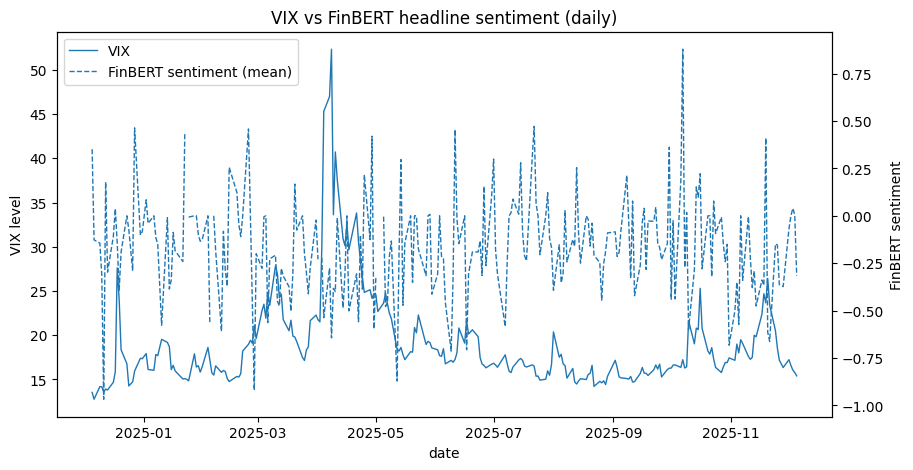

In [ ]:
# 3. Simple time series plot: VIX vs FinBERT sentiment

#I had trouble creating the plot with approprate window and legends, and I turned to chatgpt
#  by feeding it the dataframe that I have and asked for a time-series plot between VIX and FinBert Sentiment score.
#  This block is its return

plt.figure(figsize=(10, 5))
plot_df = df.set_index("date").sort_index()

# Plot VIX on left axis and FinBERT sentiment on right axis
ax1 = plot_df["VIX"].plot(label="VIX", linewidth=1)
ax1.set_ylabel("VIX level")

ax2 = ax1.twinx()
if "finbert_sentiment_mean" in plot_df.columns:
    plot_df["finbert_sentiment_mean"].plot(
        ax=ax2,
        label="FinBERT sentiment (mean)",
        linewidth=1,
        linestyle="--"
    )
    ax2.set_ylabel("FinBERT sentiment")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("VIX vs FinBERT headline sentiment (daily)")
plt.show()

In [ ]:
# I want to test the predictive power of test score for VIX, and I'm familiar with the theory of running
#   OLS regression with lagged variable. However, I'm not sure how to do it with python code, so I turned to chatgpt for help
# The following is its response.

#4. Add 1-day lag of text features to see if today’s headlines predict tomorrow’s VIX
df = df.sort_values("date")

for col in ["finbert_sentiment_mean", "tfidf_risk_score", "tfidf_optimism_score"]:
    if col in df.columns:
        df[col + "_lag1"] = df[col].shift(1)

# Prepare regression dataset: tomorrow's VIX vs yesterday's text
reg_cols = ["VIX"]
text_lag_cols = [c for c in df.columns if c.endswith("_lag1")]
reg_cols.extend(text_lag_cols)

reg_df = df[reg_cols].dropna()

print("Regression dataset shape:", reg_df.shape)
print("Regressors:", text_lag_cols)

# 5. OLS regression: VIX_t on lagged text features
Y = reg_df["VIX"]
X = reg_df[text_lag_cols]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

Regression dataset shape: (246, 4)
Regressors: ['finbert_sentiment_mean_lag1', 'tfidf_risk_score_lag1', 'tfidf_optimism_score_lag1']
                            OLS Regression Results                            
Dep. Variable:                    VIX   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     5.818
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           0.000745
Time:                        04:57:37   Log-Likelihood:                -751.99
No. Observations:                 246   AIC:                             1512.
Df Residuals:                     242   BIC:                             1526.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      

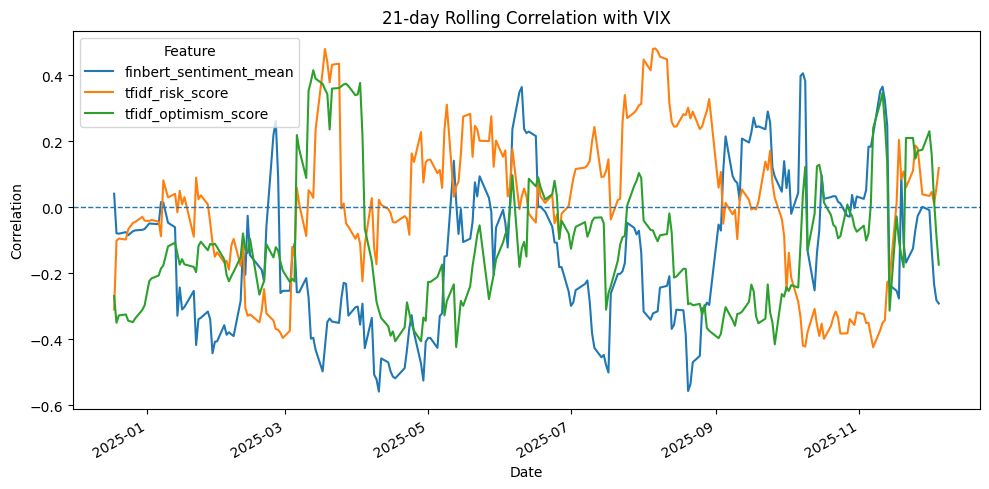

In [ ]:
# ============================================================
# Part 6: Rolling correlation over time (VIX vs text features)
# ============================================================

# I also asked chatgpt for a correlation plot, here's its response

import pandas as pd
import matplotlib.pyplot as plt

# 1. Work on a clean, sorted copy
corr_df = merged_df.copy()
corr_df["date"] = pd.to_datetime(corr_df["date"])
corr_df = corr_df.sort_values("date").set_index("date")

# 2. Choose the text-based features you want to compare with VIX
text_features = [
    "finbert_sentiment_mean",
    "tfidf_risk_score",
    "tfidf_optimism_score"
]

# 3. Keep only the ones that actually exist
text_features = [c for c in text_features if c in corr_df.columns]

# 4. Rolling window (in days). You can change 21 -> 30, 60, etc.
window = 21

for feat in text_features:
    roll_col = f"roll_corr_{feat}"
    corr_df[roll_col] = (
        corr_df[feat]
        .rolling(window=window, min_periods=10)
        .corr(corr_df["VIX"])
    )

# 5. Plot rolling correlations
plt.figure(figsize=(10, 5))

for feat in text_features:
    roll_col = f"roll_corr_{feat}"
    if roll_col in corr_df.columns:
        corr_df[roll_col].plot(label=feat)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"{window}-day Rolling Correlation with VIX")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(title="Feature")
plt.tight_layout()
plt.show()
